<a href="https://colab.research.google.com/github/Mahammad-Haroon/Data-Analysis-Projects/blob/main/Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Upload the provided dataset
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("Customers.csv")

features = ["Annual Income ($)", "Spending Score (1-100)"]

# ALWAYS scale before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# K-means labels to compare against
df["kmeans"] = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
).fit_predict(X_scaled)

print(df.shape)
display(df.head())

Saving Customers.csv to Customers (2).csv
(2000, 9)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,kmeans
0,1,Male,19,15000,39,Healthcare,1,4,2
1,2,Male,21,35000,81,Engineer,3,3,1
2,3,Female,20,86000,6,Engineer,1,1,2
3,4,Female,23,59000,77,Lawyer,0,2,1
4,5,Female,31,38000,40,Entertainment,2,6,2


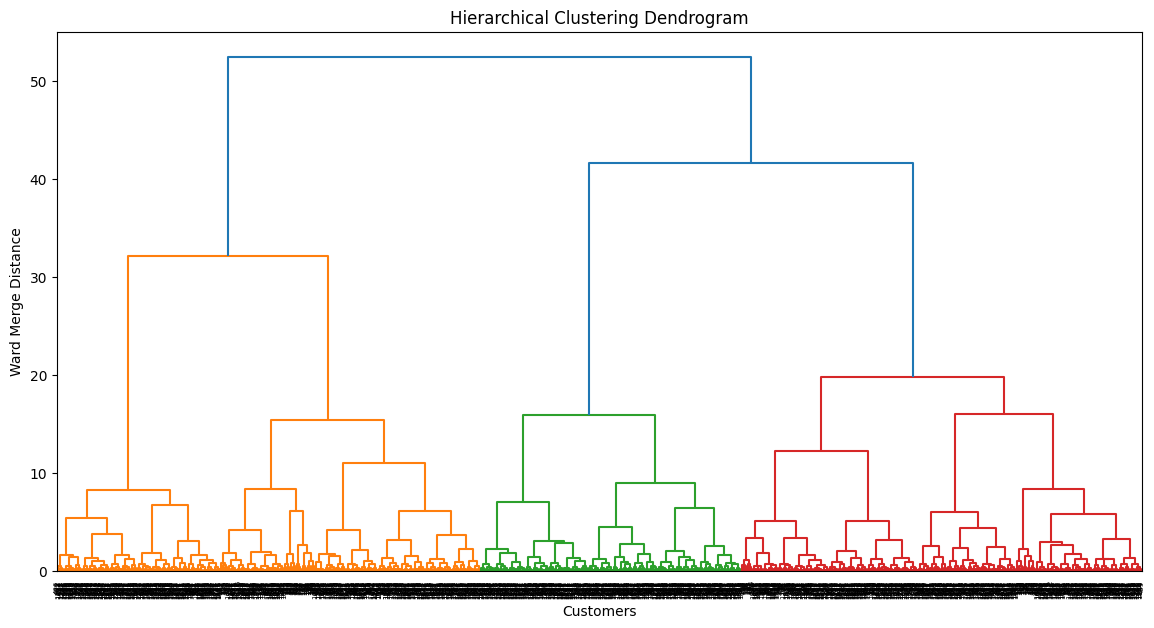

In [6]:
# Step 1: Ward linkage
Z = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(Z)

plt.xlabel("Customers")
plt.ylabel("Ward Merge Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

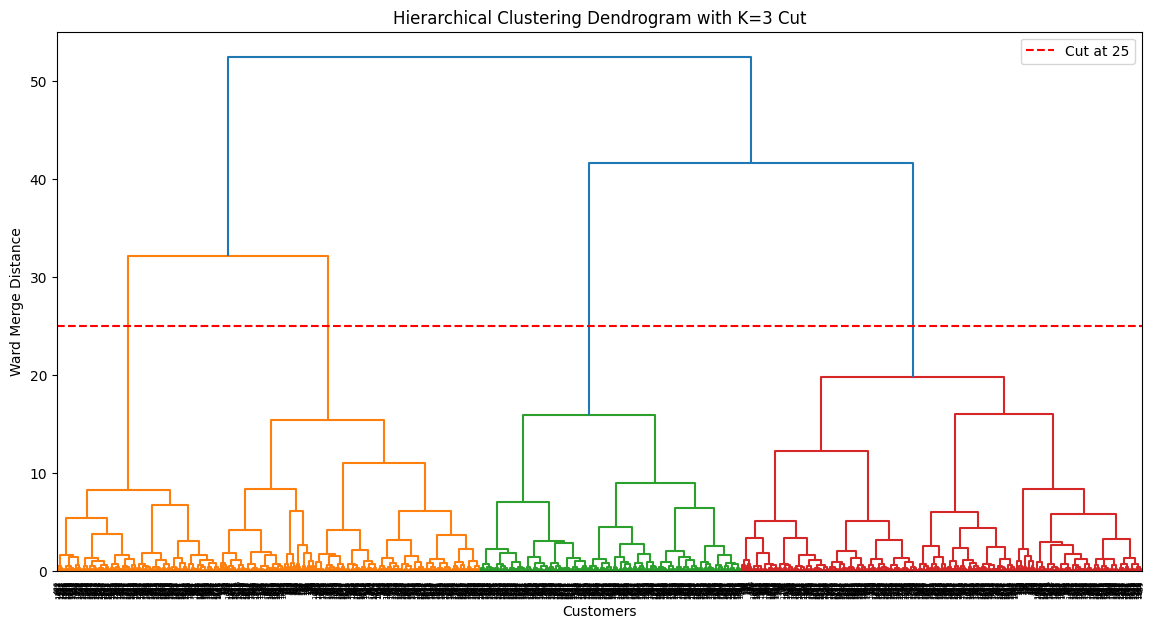

In [7]:
cut_height = 25

plt.figure(figsize=(14, 7))

dendrogram(Z)

plt.axhline(
    y=cut_height,
    color="red",
    linestyle="--",
    label=f"Cut at {cut_height}"
)

plt.xlabel("Customers")
plt.ylabel("Ward Merge Distance")
plt.title("Hierarchical Clustering Dendrogram with K=3 Cut")
plt.legend()

plt.show()

In [8]:
# Step 3: Agglomerative Hierarchical Clustering

K = 3

agg = AgglomerativeClustering(
    n_clusters=K,
    linkage="ward"
)

# Fit the hierarchical clustering model
df["hier"] = agg.fit_predict(X_scaled)

# Print cluster counts
print("Hierarchical cluster counts:")
print(df["hier"].value_counts().sort_index())

# Print cluster profile
print("\nHierarchical Cluster Profile:")
cluster_profile = df.groupby("hier")[features].mean()

display(cluster_profile)

Hierarchical cluster counts:
hier
0    781
1    738
2    481
Name: count, dtype: int64

Hierarchical Cluster Profile:


,Annual Income ($),Spending Score (1-100)
hier,,
0,104089.440461,79.564661
1,84640.750678,28.433604
2,161548.681913,39.087318


### Cluster 0 — Frequent Bargain Hunters

Cluster 0 has the lowest annual spend at approximately ₹15,000 but the highest purchase frequency at around 41 purchases. Its low average basket value of about ₹400 suggests frequent small purchases, making discounts, bundles, and loyalty rewards suitable marketing strategies.

### Cluster 1 — Premium Customers

Cluster 1 has the highest annual spend at approximately ₹75,000 and the highest average basket value at around ₹3,000. These high-value customers should be targeted with premium products, exclusive offers, personalized recommendations, and VIP loyalty benefits.

### Cluster 2 — Regular Customers

Cluster 2 has a moderate annual spend of approximately ₹45,000, purchase frequency of around 18, and average basket value of about ₹2,000. This group represents regular customers who could be encouraged to increase their spending through cross-selling, personalized promotions, and loyalty campaigns.
